In [ ]:
import os, sys, random, warnings
import numpy as np
import gym
from gym import spaces
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import defaultdict
from pythermalcomfort.models import pmv_ppd
warnings.filterwarnings('ignore')

from models.dqn import DQN, DQNAgent
from models.ppo import PPOAgent
from models.sac import SACAgent

from models.model_saver_with_loader import load_agent

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Configuration
Edit paths and test settings here.

In [ ]:
# ── Model paths ───────────────────────────────────────────────────────────────
DQN_PATH  = 'saved_models/dqn_model_no_adversary.pth'
RARL_PATH = 'saved_models/protagonist_model_with_energy.pth'
PPO_PATH  = 'saved_models/ppo_clean_trial0_run0_20260326_145912.pth'
SAC_PATH  = 'saved_models/sac_clean_trial0_run0_20260330_122802.pth'

# ── Test settings ─────────────────────────────────────────────────────────────
# TEST_FRACTIONS represents the total corrupted-user fraction.
#
# For each value f:
#   adversarial_fraction = f / 2
#   exaggerated_fraction = f / 2
#
# Since MixedBuildingEnv samples the two roles mutually exclusively:
#   P(adversarial only) = f / 2
#   P(exaggerated only) = f / 2
#   P(any corruption)   = f
#   P(both)             = 0
TEST_FRACTIONS = [0.0, 0.25, 0.50, 0.75, 1.0]

NUM_RUNS      = 1
NUM_EPISODES  = 150

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


Using device: cuda


# Comparing DQN / PPO / SAC / TD3 vs RARL in Building HVAC Gymnasium Environment
## Mixed-Adversary Environment — Mutually exclusive adversarial & exaggerated effects

## Building HVAC Gymnasium Environment — Mutually exclusive adversarial & exaggerated input

In [3]:
class MixedBuildingEnv(gym.Env):
    """
    Building HVAC environment where each user is mutually exclusively drawn each timestep:

        P(adversarial) = adversarial_fraction
        P(exaggerated) = exaggerated_fraction

    This means a user can fall into one of three buckets:
        - Normal only          (neither effect)
        - Adversarial only     (direction-flip bias)
        - Exaggerated only     (magnitude amplification)
    
    (But never both adversarial and exaggerated)

    Parameters
    ----------
    adversarial_fraction : float [0, 0.5]
        Mutually exclusive probability each user is adversarial this timestep.
    exaggerated_fraction : float [0, 0.5]
        Mutually exclusive probability each user is exaggerated this timestep.
    alpha, beta, EER     : reward weighting (same as other envs).
    """

    def __init__(self, alpha=1, beta=1, EER=11,
                 adversarial_fraction=0.15, exaggerated_fraction=0.15):
        super(MixedBuildingEnv, self).__init__()

        self.alpha = alpha
        self.beta  = beta
        self.EER   = EER

        # ── mutually exclusive probabilities ─────────────────────────────────────
        self.adversarial_fraction = adversarial_fraction
        self.exaggerated_fraction = exaggerated_fraction

        # ── room layout ───────────────────────────────────────────────────
        self.room_width, self.room_height = 800, 600

        # ── adversarial-bias state ────────────────────────────────────────
        self.prev_pmv    = 0.0
        self.pmv_history = []

        # ── per-timestep user role tracking ──────────────────────────────
        self.adversarial_users = set()   # indices flagged adversarial
        self.exaggerated_users = set()   # indices flagged exaggerated
        self.both_users        = set()   # indices flagged both
        self.is_adversarial    = False

        # ── feedback signals ──────────────────────────────────────────────
        self.user_feedback        = 0.0
        self.nonadv_user_feedback = 0.0

        # ── spaces ───────────────────────────────────────────────────────
        self.action_space = spaces.Discrete(9)
        low  = np.array([-10.0, 0.0, -3.0], dtype=np.float32)
        high = np.array([ 50.0, 1.0,  3.0], dtype=np.float32)
        self.observation_space = spaces.Box(low, high, dtype=np.float32)

        # ── building state ────────────────────────────────────────────────
        self.time_step     = 0
        self.max_steps     = 48
        self.indoor_temp   = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp  = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users     = self.generate_num_users()
        self.users         = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        self.hvac_power    = 0.0

        # ── history ───────────────────────────────────────────────────────
        self.history = {
            'indoor_temp':           [],
            'outdoor_temp':          [],
            'hvac_power':            [],
            'user_feedback':         [],
            'nonadv_user_feedback':  [],
            'occupancy':             [],
            'time':                  [],
            'is_adversarial':        [],
            'n_adversarial_users':   [],
            'n_exaggerated_users':   [],
            'n_both_users':          [],
        }

    # ── environment helpers ───────────────────────────────────────────────────

    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)
        return temp + np.random.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:
            return np.random.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:
            return np.random.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:
            return np.random.uniform(0.2, 0.5)
        else:
            return np.random.uniform(0.0, 0.1)

    def generate_num_users(self):
        return int(self.occupancy_level * 1000)

    def generate_users(self):
        return [
            {
                'x':   random.randint(50, self.room_width  - 50),
                'y':   random.randint(50, self.room_height - 50),
                'met': np.random.uniform(1.0, 1.5),
                'clo': np.random.uniform(0.5, 1.0),
            }
            for _ in range(self.num_users)
        ]

    def calculate_pmv(self, met, clo):
        result = pmv_ppd(
            tdb=self.indoor_temp, tr=self.indoor_temp,
            vr=0.1, rh=50.0, met=met, clo=clo, standard='ASHRAE'
        )
        return float(result['pmv'])

    # ── corruption functions ──────────────────────────────────────────────────

    def calculate_adversarial_bias(self, current_pmv):
        """Direction-flipping bias computed from population mean PMV."""
        pmv_direction = current_pmv - self.prev_pmv
        self.pmv_history.append(current_pmv)
        if len(self.pmv_history) > 5:
            self.pmv_history.pop(0)
        pmv_trend = (np.mean(np.diff(self.pmv_history))
                     if len(self.pmv_history) > 1 else 0.0)

        base_bias = -1.0 if current_pmv > 0 else 1.0
        if (pmv_direction * current_pmv) < 0:
            base_bias *= 1.5

        trend_factor    = -pmv_trend * 1.5
        occupancy_scale = 0.5 + self.occupancy_level
        time_of_day     = (self.time_step % self.max_steps) / self.max_steps * 24.0
        time_factor     = 1.5 if (9 <= time_of_day < 17) else 1.0

        return float(np.clip(
            (base_bias + trend_factor) * occupancy_scale * time_factor,
            -2.0, 2.0
        ))

    def apply_exaggerated(self, pmv):
        """Bell-shaped magnitude amplifier applied to a single PMV value."""
        exaggeration_strength = 1.5
        abs_pmv = abs(pmv)
        scale   = abs_pmv * (3.0 - abs_pmv) / 2.25   # peaks at |pmv| = 1.5
        exaggerated = (pmv
                       + exaggeration_strength * np.sign(pmv) * scale
                       + np.random.normal(0.0, 0.08))
        return float(np.clip(exaggerated, -3.0, 3.0))

    # ── feedback generation ───────────────────────────────────────────────────

    def generate_user_feedback(self):
        if self.num_users == 0:
            self.adversarial_users = set()
            self.exaggerated_users = set()
            self.both_users        = set()
            self.is_adversarial    = False
            self.nonadv_user_feedback = 0.0
            self.prev_pmv = 0.0
            return 0.0

        # ── mutually exclusive draws per user ──────────────────────────
        # Each user has a chance to be adversarial OR exaggerated, but overlap is not allowed.
        p_adv = self.adversarial_fraction
        p_exag = self.exaggerated_fraction

        if p_adv + p_exag > 1.0:
            raise ValueError(
                f"Invalid mutually exclusive fractions: "
                f"adversarial_fraction + exaggerated_fraction = {p_adv + p_exag:.2f} > 1.0"
            )

        u = np.random.random(self.num_users)

        is_adv = u < p_adv
        is_exag = (u >= p_adv) & (u < p_adv + p_exag)

        self.adversarial_users = set(np.where(is_adv)[0].tolist())
        self.exaggerated_users = set(np.where(is_exag)[0].tolist())
        self.both_users        = self.adversarial_users & self.exaggerated_users
        self.is_adversarial    = bool(is_adv.any() or is_exag.any())

        # ── compute clean PMV for every user ─────────────────────────────
        clean_pmv_values = []
        for user in self.users:
            met = user['met']
            clo = user['clo']
            if self.indoor_temp > 26:
                clo = max(0.5, clo - 0.1)
            elif self.indoor_temp < 20:
                clo = min(1.0, clo + 0.1)
            clean_pmv_values.append(self.calculate_pmv(met, clo))

        base_pmv = float(np.mean(clean_pmv_values))

        # Adversarial bias: one value derived from population mean PMV
        adv_bias = (self.calculate_adversarial_bias(base_pmv)
                    if self.adversarial_users else 0.0)

        # ── apply corruption per user ─────────────────────────────────────
        # Mutually exclusive corruption:
        # adversarial users receive direction-flip bias;
        # exaggerated users receive magnitude amplification;
        # no user receives both.
        final_pmv_values = []
        for idx, pmv in enumerate(clean_pmv_values):
            corrupted = float(pmv)

            if is_adv[idx]:
                # direction-flip with additive bias + noise
                corrupted = corrupted + adv_bias + np.random.normal(0, 0.2)
                corrupted = float(np.clip(corrupted, -3.0, 3.0))

            if is_exag[idx]:
                # magnitude amplification (applied to whatever corrupted is)
                corrupted = self.apply_exaggerated(corrupted)

            final_pmv_values.append(corrupted)

        self.nonadv_user_feedback = float(np.mean(clean_pmv_values))
        self.prev_pmv = base_pmv

        return float(np.clip(np.mean(final_pmv_values), -3.0, 3.0))

    # ── step / reset ──────────────────────────────────────────────────────────

    def step(self, action, adversary_action=None):
        n_disruptive = len(self.adversarial_users | self.exaggerated_users)
        disruptive_fraction = n_disruptive / self.num_users if self.num_users > 0 else 0.0

        if adversary_action is not None:
            self.setpoint_temp = 22 + action
            base_influence = (adversary_action - 4) * 0.5
            if disruptive_fraction > 0:
                if abs(self.user_feedback) > 1.0:
                    base_influence *= 1.2
                if self.occupancy_level > 0.7:
                    base_influence *= 1.5
            self.setpoint_temp += base_influence
        else:
            self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power  = abs(temp_difference) * 10 / self.EER

        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        solar_gain  = max(0.0, np.sin((time_of_day - 6) * np.pi / 12) * 0.05)
        outdoor_inf = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_inf    = (self.setpoint_temp - self.indoor_temp) * 0.5
        self.indoor_temp += outdoor_inf + hvac_inf + solar_gain

        self.time_step += 1
        done = self.time_step >= self.max_steps

        self.outdoor_temp    = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users       = self.generate_num_users()
        self.users           = self.generate_users()
        self.user_feedback   = self.generate_user_feedback()

        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty  = self.hvac_power / 1000.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        reward /= 10.0

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['nonadv_user_feedback'].append(self.nonadv_user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)
        self.history['is_adversarial'].append(self.is_adversarial)
        self.history['n_adversarial_users'].append(len(self.adversarial_users))
        self.history['n_exaggerated_users'].append(len(self.exaggerated_users))
        self.history['n_both_users'].append(len(self.both_users))

        state = np.array(
            [self.outdoor_temp, self.occupancy_level, self.user_feedback],
            dtype=np.float32
        )
        return state, reward, done, {}

    def get_pmv_wo_adv(self):
        if self.num_users == 0:
            return -self.beta * (self.hvac_power / 100.0) / 10.0
        comfort_penalty = abs(self.nonadv_user_feedback) * self.occupancy_level
        energy_penalty  = self.hvac_power / 1000.0
        return -(self.alpha * comfort_penalty + self.beta * energy_penalty) / 10.0

    def reset(self):
        self.time_step     = 0
        self.indoor_temp   = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp  = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users     = self.generate_num_users()
        self.users         = self.generate_users()
        self.hvac_power    = 0.0
        self.is_adversarial = False
        self.prev_pmv      = 0.0
        self.pmv_history   = []
        self.adversarial_users = set()
        self.exaggerated_users = set()
        self.both_users        = set()
        self.nonadv_user_feedback = 0.0
        self.user_feedback = self.generate_user_feedback()
        for key in self.history:
            self.history[key] = []
        return np.array(
            [self.outdoor_temp, self.occupancy_level, self.user_feedback],
            dtype=np.float32
        )

    def render(self):
        pass

## Comparing RL baselines vs RARL model
**IMPORTANT NOTE**:
- RARL HIL is trained clean offline (with simulated adversary), deployed online with mutually exclusive mixed input
- RL baselines trained clean offline, deployed online with mutually exclusive mixed input

In [4]:
def eval_episode(env, policy_net, device):
    """Run one episode with a fixed policy_net (no gradient, no replay)."""
    state = env.reset()
    ep_reward, done = 0.0, False
    while not done:
        t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            action = policy_net(t).max(1).indices.item()
        state, r, done, _ = env.step(action)
        ep_reward += r
    return ep_reward


def run_tests(policy_net, env_class, adversarial_fraction, exaggerated_fraction,
              device, num_runs=3, num_episodes=150):
    """Evaluate policy_net for num_runs x num_episodes episodes."""
    env = env_class(adversarial_fraction=adversarial_fraction,
                    exaggerated_fraction=exaggerated_fraction)
    all_rewards = []
    for run in range(num_runs):
        run_rewards = [
            eval_episode(env, policy_net, device)
            for _ in range(num_episodes)
        ]
        all_rewards.append(run_rewards)
        print(f'  run {run+1}/{num_runs}  avg={np.mean(run_rewards):.4f}')
    return np.array(all_rewards)


def test_all_ratios(agents_dict, fractions, device,
                    num_runs=3, num_episodes=150):
    """
    Sweep total corruption fraction.

    For every value f in fractions, the environment is created with:
        adversarial_fraction = f / 2
        exaggerated_fraction = f / 2

    Because the two effects are mutually exclusive per user:
        P(adversarial) = f / 2
        P(exaggerated) = f / 2
        P(any corruption) = f
        P(both) = 0

    agents_dict : {label: policy_net_module}
    fractions   : list of total corruption fractions to sweep
    Returns     : {label: {fraction: np.array(num_runs, num_episodes)}}
    """
    results = {label: {} for label in agents_dict}

    for f in fractions:
        adv_frac = f / 2
        exag_frac = f / 2

        expected_any = adv_frac + exag_frac
        expected_both = 0.0

        print(
            f'\n─── Total corruption={f:.0%} '
            f'| adversarial={adv_frac:.1%} '
            f'| exaggerated={exag_frac:.1%} '
            f'| E[any]={expected_any:.0%} '
            f'| E[both]={expected_both:.0%} ───'
        )

        for label, net in agents_dict.items():
            print(f'  [{label}]')
            results[label][f] = run_tests(
                net,
                MixedBuildingEnv,
                adversarial_fraction=adv_frac,
                exaggerated_fraction=exag_frac,
                device=device,
                num_runs=num_runs,
                num_episodes=num_episodes
            )

    return results


def plot_results(results, fractions,
                 title='Performance vs Total Corruption Fraction'):
    colors = {
        'DQN':      'purple',
        'RARL':     'navy',
        'PPO':      'steelblue',
        'RARL_PPO': 'deepskyblue',
        'SAC':      'darkorange',
        'TD3':      'forestgreen',
    }

    fig, axes = plt.subplots(
        1,
        len(fractions),
        figsize=(7 * len(fractions), 5),
        sharey=True
    )

    if len(fractions) == 1:
        axes = [axes]

    fig.suptitle(title, fontsize=14)

    for ax, f in zip(axes, fractions):
        adv_frac = f / 2
        exag_frac = f / 2
        expected_both = 0.0

        for label, ratio_results in results.items():
            data = ratio_results[f]
            m = np.mean(data, axis=0)

            ax.plot(
                m,
                label=label,
                color=colors.get(label),
                linewidth=2
            )

            ax.fill_between(
                range(len(m)),
                np.min(data, axis=0),
                np.max(data, axis=0),
                color=colors.get(label),
                alpha=0.15
            )

        ax.set_title(
            f'Total corruption={f:.0%}\n'
            f'Adv={adv_frac:.1%}, Exag={exag_frac:.1%}, Both={expected_both:.0%}',
            fontsize=11
        )

        ax.set_xlabel('Episode')
        ax.set_ylabel('Total Reward')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_statistics(results, fractions):
    print('\n=== Average Reward Statistics ===')

    for f in fractions:
        adv_frac = f / 2
        exag_frac = f / 2
        expected_any = adv_frac + exag_frac
        expected_both = 0.0

        print(
            f'\n  Total corruption={f:.0%}'
            f'  Adv={adv_frac:.1%}'
            f'  Exag={exag_frac:.1%}'
            f'  E[any]={expected_any:.0%}'
            f'  E[both]={expected_both:.0%}'
        )

        rarl_avg = np.mean(results['RARL'][f]) if 'RARL' in results else None

        for label, ratio_results in results.items():
            avg = np.mean(ratio_results[f])
            std = np.std([np.mean(r) for r in ratio_results[f]])

            imp = (
                f'  ({((avg - rarl_avg) / abs(rarl_avg) * 100):+.1f}% vs RARL)'
                if rarl_avg is not None and label != 'RARL'
                else ''
            )

            print(f'    {label:8s}: {avg:.4f} ± {std:.4f}{imp}')


print('Test helpers defined.')


Test helpers defined.


## Load trained models

In [5]:
n_obs, n_act = 3, 9

dqn_agent = DQNAgent(n_observations=n_obs, n_actions=n_act, device=device)
load_agent(dqn_agent, DQN_PATH)

rarl_agent = DQNAgent(n_observations=n_obs, n_actions=n_act, device=device)
load_agent(rarl_agent, RARL_PATH)

ppo_agent = PPOAgent(n_observations=n_obs, n_actions=n_act, device=device)
load_agent(ppo_agent, PPO_PATH)

sac_agent = SACAgent(n_observations=n_obs, n_actions=n_act, device=device)
load_agent(sac_agent, SAC_PATH)

# td3_agent = TD3Agent(n_observations=n_obs, n_actions=n_act, device=device)
# load_agent(td3_agent, TD3_PATH)

AGENTS = {
    'DQN':  dqn_agent.policy_net,
    'RARL': rarl_agent.policy_net,
    'PPO':  ppo_agent.policy_net,
    'SAC':  sac_agent.policy_net,
    # 'TD3':  td3_agent.policy_net,
}
print('All models loaded.')

  [loaded] saved_models/dqn_model_no_adversary.pth
  [loaded] saved_models/protagonist_model_with_energy.pth
  [loaded] saved_models/ppo_clean_trial0_run0_20260326_145912.pth
  [loaded] saved_models/sac_clean_trial0_run0_20260330_122802.pth
All models loaded.


## Run evaluation

In [6]:
results = test_all_ratios(
    AGENTS,
    fractions     = TEST_FRACTIONS,
    device        = device,
    num_runs      = NUM_RUNS,
    num_episodes  = NUM_EPISODES,
)



─── Total corruption=0% | adversarial=0.0% | exaggerated=0.0% | E[any]=0% | E[both]=0% ───
  [DQN]
  run 1/1  avg=-0.1195
  [RARL]
  run 1/1  avg=-0.1187
  [PPO]
  run 1/1  avg=-0.1491
  [SAC]
  run 1/1  avg=-0.0870

─── Total corruption=25% | adversarial=12.5% | exaggerated=12.5% | E[any]=25% | E[both]=0% ───
  [DQN]
  run 1/1  avg=-0.2484
  [RARL]
  run 1/1  avg=-0.2112
  [PPO]
  run 1/1  avg=-0.2385
  [SAC]
  run 1/1  avg=-0.2234

─── Total corruption=50% | adversarial=25.0% | exaggerated=25.0% | E[any]=50% | E[both]=0% ───
  [DQN]
  run 1/1  avg=-0.4915
  [RARL]
  run 1/1  avg=-0.3701
  [PPO]
  run 1/1  avg=-0.4751
  [SAC]
  run 1/1  avg=-0.4511

─── Total corruption=75% | adversarial=37.5% | exaggerated=37.5% | E[any]=75% | E[both]=0% ───
  [DQN]
  run 1/1  avg=-0.7452
  [RARL]
  run 1/1  avg=-0.4763
  [PPO]
  run 1/1  avg=-0.7306
  [SAC]
  run 1/1  avg=-0.6688

─── Total corruption=100% | adversarial=50.0% | exaggerated=50.0% | E[any]=100% | E[both]=0% ───
  [DQN]
  run 1/1  avg

## Results


=== Average Reward Statistics ===

  Total corruption=0%  Adv=0.0%  Exag=0.0%  E[any]=0%  E[both]=0%
    DQN     : -0.1195 ± 0.0000  (-0.7% vs RARL)
    RARL    : -0.1187 ± 0.0000
    PPO     : -0.1491 ± 0.0000  (-25.6% vs RARL)
    SAC     : -0.0870 ± 0.0000  (+26.7% vs RARL)

  Total corruption=25%  Adv=12.5%  Exag=12.5%  E[any]=25%  E[both]=0%
    DQN     : -0.2484 ± 0.0000  (-17.6% vs RARL)
    RARL    : -0.2112 ± 0.0000
    PPO     : -0.2385 ± 0.0000  (-12.9% vs RARL)
    SAC     : -0.2234 ± 0.0000  (-5.8% vs RARL)

  Total corruption=50%  Adv=25.0%  Exag=25.0%  E[any]=50%  E[both]=0%
    DQN     : -0.4915 ± 0.0000  (-32.8% vs RARL)
    RARL    : -0.3701 ± 0.0000
    PPO     : -0.4751 ± 0.0000  (-28.4% vs RARL)
    SAC     : -0.4511 ± 0.0000  (-21.9% vs RARL)

  Total corruption=75%  Adv=37.5%  Exag=37.5%  E[any]=75%  E[both]=0%
    DQN     : -0.7452 ± 0.0000  (-56.5% vs RARL)
    RARL    : -0.4763 ± 0.0000
    PPO     : -0.7306 ± 0.0000  (-53.4% vs RARL)
    SAC     : -0.6688 ± 

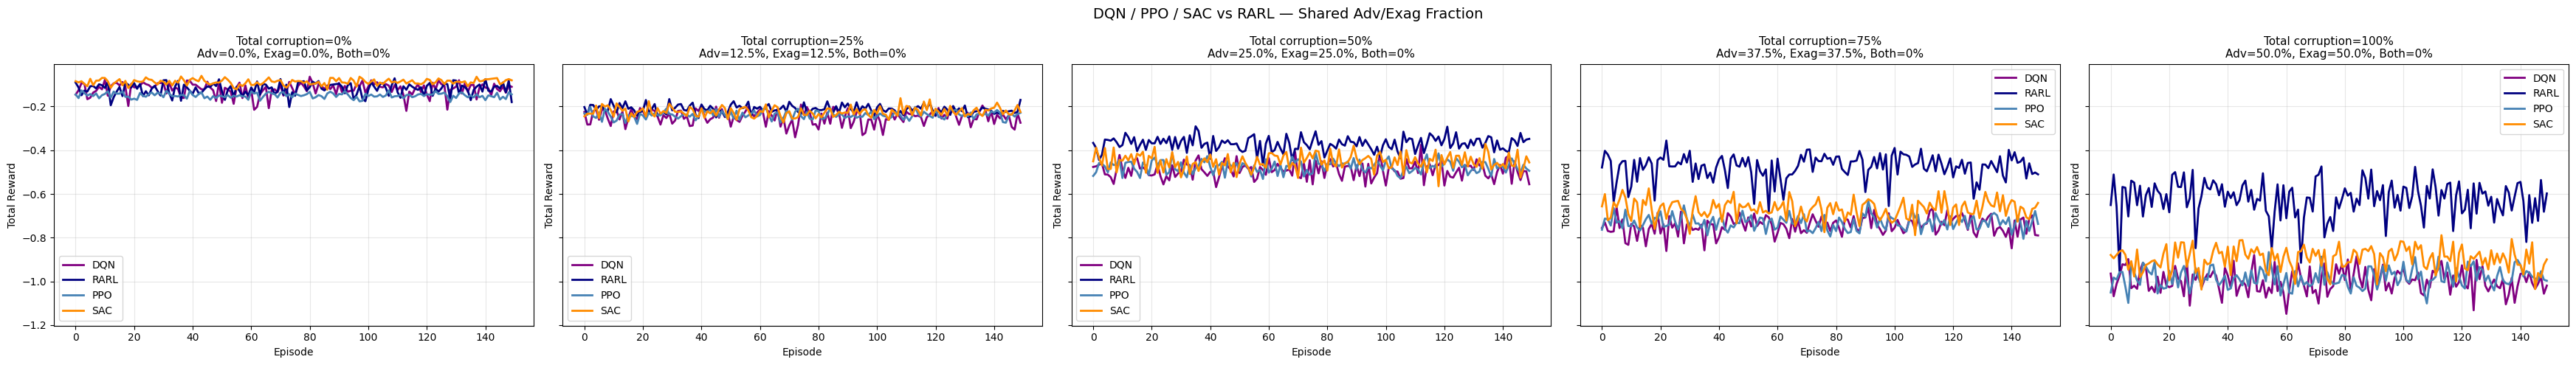

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/jetwei/miniconda3/envs/hvac/lib/python3.11/sit

In [7]:
print_statistics(results, TEST_FRACTIONS)
plot_results(
    results, TEST_FRACTIONS,
    title='DQN / PPO / SAC vs RARL — Shared Adv/Exag Fraction'
)
